# 01 — Build Daily Feature Dataset

Produces `data/daily_features.csv` — one row per (ticker, trading day) with:
- Market features: open, high, low, close, volume, return_1d, return_3d, rolling_volatility_5d
- Sentiment features: article_count, sentiment_mean, sentiment_max, sentiment_min, sentiment_std, positive_count, negative_count

**No future leakage** — sentiment is aggregated only from articles published on or before each trading day.

In [30]:
import sys
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm

# replacing vader with finBERT llm
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# PROJECT_ROOT = Path('..').resolve()
# DATA_DIR = PROJECT_ROOT / 'data'
# FILES_DIR = PROJECT_ROOT / 'files'
# DATA_DIR.mkdir(exist_ok=True)
# sys.path.insert(0, str(PROJECT_ROOT / 'src'))

# Base paths
PROJECT_ROOT = Path('..').resolve() / 'llm'  # all outputs here
EXTERNAL_ROOT = Path('..').resolve() 

# Original paths
FILES_DIR = EXTERNAL_ROOT / 'files'
DATA_DIR = EXTERNAL_ROOT / 'data'

# LLM-specific paths
LLM_FILE_DIR = PROJECT_ROOT / 'files'
LLM_DATA_DIR = PROJECT_ROOT / 'data'

# Create folders if they don't exist
LLM_FILE_DIR.mkdir(exist_ok=True, parents=True)
LLM_DATA_DIR.mkdir(exist_ok=True, parents=True)

from dataset_builder import DatasetPaths, build_dataset

print('Project root:', PROJECT_ROOT)
print('External root:', EXTERNAL_ROOT)


Project root: /Users/jasminevu/Documents/Fourth_Year/CS4453/Final Group Project/RL-Project/llm
External root: /Users/jasminevu/Documents/Fourth_Year/CS4453/Final Group Project/RL-Project


## 1. Load Market Data

In [18]:
TICKERS = ['NVDA', 'GOOG', 'TSLA']
TICKER_FILE_MAP = {
    'NVDA': FILES_DIR / 'NVDA_q4_2025.csv',
    'GOOG': FILES_DIR / 'GOOG_q4_2025.csv',
    'TSLA': FILES_DIR / 'TSLA_q4_2025.csv',
}

market_frames = []
for ticker, path in TICKER_FILE_MAP.items():
    df = pd.read_csv(path, parse_dates=['Date'])
    df = df.rename(columns={'Date': 'date'})
    df['ticker'] = ticker
    # Keep only raw OHLCV — we'll recompute derived features cleanly
    df = df[['date', 'ticker', 'open', 'high', 'low', 'close', 'volume']]
    market_frames.append(df)

market = pd.concat(market_frames, ignore_index=True)
market = market.sort_values(['ticker', 'date']).reset_index(drop=True)
market['date'] = pd.to_datetime(market['date'])

print('Market data shape:', market.shape)
print('Date range:', market['date'].min().date(), '→', market['date'].max().date())
market.head()

Market data shape: (192, 7)
Date range: 2025-10-01 → 2025-12-31


,date,ticker,open,high,low,close,volume
0,2025-10-01,GOOG,241.179993,247.149994,239.199997,245.539993,23967700
1,2025-10-02,GOOG,245.639999,247.634995,243.104996,246.429993,20657500
2,2025-10-03,GOOG,245.229996,247.117996,242.470001,246.449997,19941400
3,2025-10-06,GOOG,245.779999,252.199997,245.690002,251.509995,18309000
4,2025-10-07,GOOG,248.929993,251.550003,246.809998,247.130005,13811200


## 2. Compute Market Features

In [19]:
def compute_market_features(df):
    df = df.copy().sort_values('date')
    df['return_1d'] = df['close'].pct_change(1)
    df['return_3d'] = df['close'].pct_change(3)
    df['rolling_volatility_5d'] = df['return_1d'].rolling(5).std()
    return df

market = market.groupby('ticker', group_keys=False).apply(compute_market_features)
market = market.reset_index(drop=True)

print('Sample NVDA:')
market[market['ticker'] == 'NVDA'][['date', 'close', 'return_1d', 'return_3d', 'rolling_volatility_5d']].head(8)

Sample NVDA:


,date,close,return_1d,return_3d,rolling_volatility_5d
64,2025-10-01,187.240005,NaN,NaN,NaN
65,2025-10-02,188.889999,0.008812,NaN,NaN
66,2025-10-03,187.619995,-0.006724,NaN,NaN
67,2025-10-06,185.539993,-0.011086,-0.009079,NaN
68,2025-10-07,185.039993,-0.002695,-0.020382,NaN
69,2025-10-08,189.110001,0.021995,0.007942,0.013375
70,2025-10-09,192.570007,0.018296,0.037889,0.015130
71,2025-10-10,183.160004,-0.048865,-0.010160,0.028446


## 3. Load Articles and Score Sentiment (VADER)

VADER is a lexicon-based sentiment analyzer that works well on short financial text.
We score the **headline + summary** (not full_text) — fast, and captures the signal.

In [6]:
articles = pd.read_csv(FILES_DIR / 'q4_articles' / 'raw_articles_q4_2025.csv', parse_dates=['date_utc'])

# Filter to Q4 2025
articles = articles[articles['date_utc'] >= '2025-10-01'].copy()
articles['date'] = pd.to_datetime(articles['date_utc']).dt.normalize()

# Normalize ticker (articles use GOOGL, market uses GOOG)
articles['ticker'] = articles['ticker'].replace({'GOOGL': 'GOOG'})

print('Q4 articles:', len(articles))
print(articles['ticker'].value_counts())
articles[['ticker', 'date', 'headline', 'source_tier']].head()

Q4 articles: 2452
ticker
NVDA    834
TSLA    813
GOOG    805
Name: count, dtype: int64


,ticker,date,headline,source_tier
0,GOOG,2025-12-31,Google wraps up best year on Wall Street since...,high
1,GOOG,2025-12-31,Space and defense boom lifted these satellite ...,high
2,GOOG,2025-12-29,"Meta acquires intelligent agent firm Manus, ca...",high
3,GOOG,2025-12-29,Jim Cramer’s guide to investing: Pick out the ...,high
4,GOOG,2025-12-29,Talk of the Tape: Next phase of the AI trade,high


In [ ]:
analyzer = SentimentIntensityAnalyzer()

def score_article(row):
    # Combine headline and summary for richer signal
    headline = str(row['headline']) if pd.notna(row['headline']) else ''
    summary = str(row['summary']) if pd.notna(row['summary']) else ''
    text = f"{headline}. {summary}"
    scores = analyzer.polarity_scores(text)
    return scores['compound']  # -1 (very negative) to +1 (very positive)

tqdm.pandas(desc='Scoring articles')
articles['sentiment_vader'] = articles.progress_apply(score_article, axis=1)

print('\nSentiment distribution:')
print(articles['sentiment_vader'].describe())

# Quick sanity check
articles[['headline', 'sentiment_vader']].sort_values('sentiment_vader').head(3)

In [ ]:
articles[['headline', 'sentiment_vader']].sort_values('sentiment_vader', ascending=False).head(3)

## 3. Load Articles and Score Sentiment (FinBERT)

In [7]:
articles = pd.read_csv(FILES_DIR / 'q4_articles' / 'raw_articles_q4_2025.csv', parse_dates=['date_utc'])

# Filter to Q4 2025
articles = articles[articles['date_utc'] >= '2025-10-01'].copy()
articles['date'] = pd.to_datetime(articles['date_utc']).dt.normalize()

# Normalize ticker (articles use GOOGL, market uses GOOG)
articles['ticker'] = articles['ticker'].replace({'GOOGL': 'GOOG'})

print('Q4 articles:', len(articles))
print(articles['ticker'].value_counts())
articles[['ticker', 'date', 'headline', 'source_tier']].head()

Q4 articles: 2452
ticker
NVDA    834
TSLA    813
GOOG    805
Name: count, dtype: int64


,ticker,date,headline,source_tier
0,GOOG,2025-12-31,Google wraps up best year on Wall Street since...,high
1,GOOG,2025-12-31,Space and defense boom lifted these satellite ...,high
2,GOOG,2025-12-29,"Meta acquires intelligent agent firm Manus, ca...",high
3,GOOG,2025-12-29,Jim Cramer’s guide to investing: Pick out the ...,high
4,GOOG,2025-12-29,Talk of the Tape: Next phase of the AI trade,high


In [11]:
model_name = "yiyanghkust/finbert-tone"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    use_safetensors=True  # doesn't work if I remove this
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# map class indices to labels (0 = neutral, 1 = pos, -1 = neg)
labels = model.config.id2label
sent_map = {0: 0, 1: 1, 2: -1}

In [12]:
def score_articles_finbert(df, batch_size=16):
    # Prepare text: Combine headline and summary as you did with VADER
    df['combined_text'] = df['headline'].fillna('') + ". " + df['summary'].fillna('')
    texts = df['combined_text'].tolist()
    all_scores = []

    for i in tqdm(range(0, len(texts), batch_size), desc="FinBERT Scoring"):
        batch_texts = texts[i : i + batch_size]
        
        inputs = tokenizer(
            batch_texts, 
            return_tensors="pt", 
            padding=True, 
            truncation=True, 
            max_length=512
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            predictions = torch.argmax(outputs.logits, dim=-1)
            # Map predictions to 1, 0, -1
            scores = [sent_map[p.item()] for p in predictions]
            all_scores.extend(scores)

    return all_scores

# Run the scoring
articles['sentiment_score'] = score_articles_finbert(articles)

FinBERT Scoring:   0%|          | 0/154 [00:00<?, ?it/s]

## 4. Aggregate Sentiment to Daily Level

In [ ]:
def aggregate_daily_sentiment(df):
    agg = df.groupby(['ticker', 'date'])['sentiment_vader'].agg(
        article_count='count',
        sentiment_mean='mean',
        sentiment_max='max',
        sentiment_min='min',
        sentiment_std='std',
    ).reset_index()
    
    # Positive/negative counts
    pos = df[df['sentiment_vader'] > 0.05].groupby(['ticker', 'date']).size().reset_index(name='positive_count')
    neg = df[df['sentiment_vader'] < -0.05].groupby(['ticker', 'date']).size().reset_index(name='negative_count')
    
    agg = agg.merge(pos, on=['ticker', 'date'], how='left')
    agg = agg.merge(neg, on=['ticker', 'date'], how='left')
    agg[['positive_count', 'negative_count']] = agg[['positive_count', 'negative_count']].fillna(0).astype(int)
    agg['sentiment_std'] = agg['sentiment_std'].fillna(0)
    
    return agg

daily_sentiment = aggregate_daily_sentiment(articles)

print('Daily sentiment rows:', len(daily_sentiment))
daily_sentiment.head()

### LLM version

In [13]:
def aggregate_daily_sentiment_finbert(df):
    agg = df.groupby(['ticker', 'date'])['sentiment_score'].agg(
        article_count='count',
        sentiment_mean='mean',
        sentiment_max='max',
        sentiment_min='min',
        sentiment_std='std',
    ).reset_index()
    
    # Positive/negative counts
    pos = df[df['sentiment_score'] == 1].groupby(['ticker', 'date']).size().reset_index(name='positive_count')
    neg = df[df['sentiment_score'] == -1].groupby(['ticker', 'date']).size().reset_index(name='negative_count')
    
    agg = agg.merge(pos, on=['ticker', 'date'], how='left')
    agg = agg.merge(neg, on=['ticker', 'date'], how='left')
    
    agg[['positive_count', 'negative_count']] = agg[['positive_count', 'negative_count']].fillna(0).astype(int)
    agg['sentiment_std'] = agg['sentiment_std'].fillna(0)
    
    # Net sentiment
    agg['net_sentiment_score'] = (agg['positive_count'] - agg['negative_count']) / agg['article_count']
    
    return agg

daily_sentiment = aggregate_daily_sentiment_finbert(articles)

In [31]:
daily_sentiment.head()

,ticker,date,article_count,sentiment_mean,sentiment_max,sentiment_min,sentiment_std,positive_count,negative_count,net_sentiment_score
0,GOOG,2025-10-27,22,0.454545,1,-1,0.595801,11,1,0.454545
1,GOOG,2025-10-28,48,0.395833,1,-1,0.706793,25,6,0.395833
2,GOOG,2025-10-29,84,0.547619,1,-1,0.647605,53,7,0.547619
3,GOOG,2025-10-30,88,0.295455,1,-1,0.775473,43,17,0.295455
4,GOOG,2025-11-23,1,1.000000,1,1,0.000000,1,0,1.000000


## 5. Merge Market + Sentiment

In [14]:
daily = market.merge(daily_sentiment, on=['ticker', 'date'], how='left')

# Fill sentiment columns with 0 on days with no articles
sentiment_cols = ['article_count', 'sentiment_mean', 'sentiment_max', 'sentiment_min',
                  'sentiment_std', 'positive_count', 'negative_count']
daily[sentiment_cols] = daily[sentiment_cols].fillna(0)

daily = daily.sort_values(['ticker', 'date']).reset_index(drop=True)

print('Final dataset shape:', daily.shape)
print('Columns:', list(daily.columns))
daily.head()

Final dataset shape: (192, 18)
Columns: ['date', 'ticker', 'open', 'high', 'low', 'close', 'volume', 'return_1d', 'return_3d', 'rolling_volatility_5d', 'article_count', 'sentiment_mean', 'sentiment_max', 'sentiment_min', 'sentiment_std', 'positive_count', 'negative_count', 'net_sentiment_score']


,date,ticker,open,high,low,close,volume,return_1d,return_3d,rolling_volatility_5d,article_count,sentiment_mean,sentiment_max,sentiment_min,sentiment_std,positive_count,negative_count,net_sentiment_score
0,2025-10-01,GOOG,241.179993,247.149994,239.199997,245.539993,23967700,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,2025-10-02,GOOG,245.639999,247.634995,243.104996,246.429993,20657500,0.003625,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
2,2025-10-03,GOOG,245.229996,247.117996,242.470001,246.449997,19941400,0.000081,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3,2025-10-06,GOOG,245.779999,252.199997,245.690002,251.509995,18309000,0.020532,0.024314,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,2025-10-07,GOOG,248.929993,251.550003,246.809998,247.130005,13811200,-0.017415,0.002841,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


## 6. Quality Check

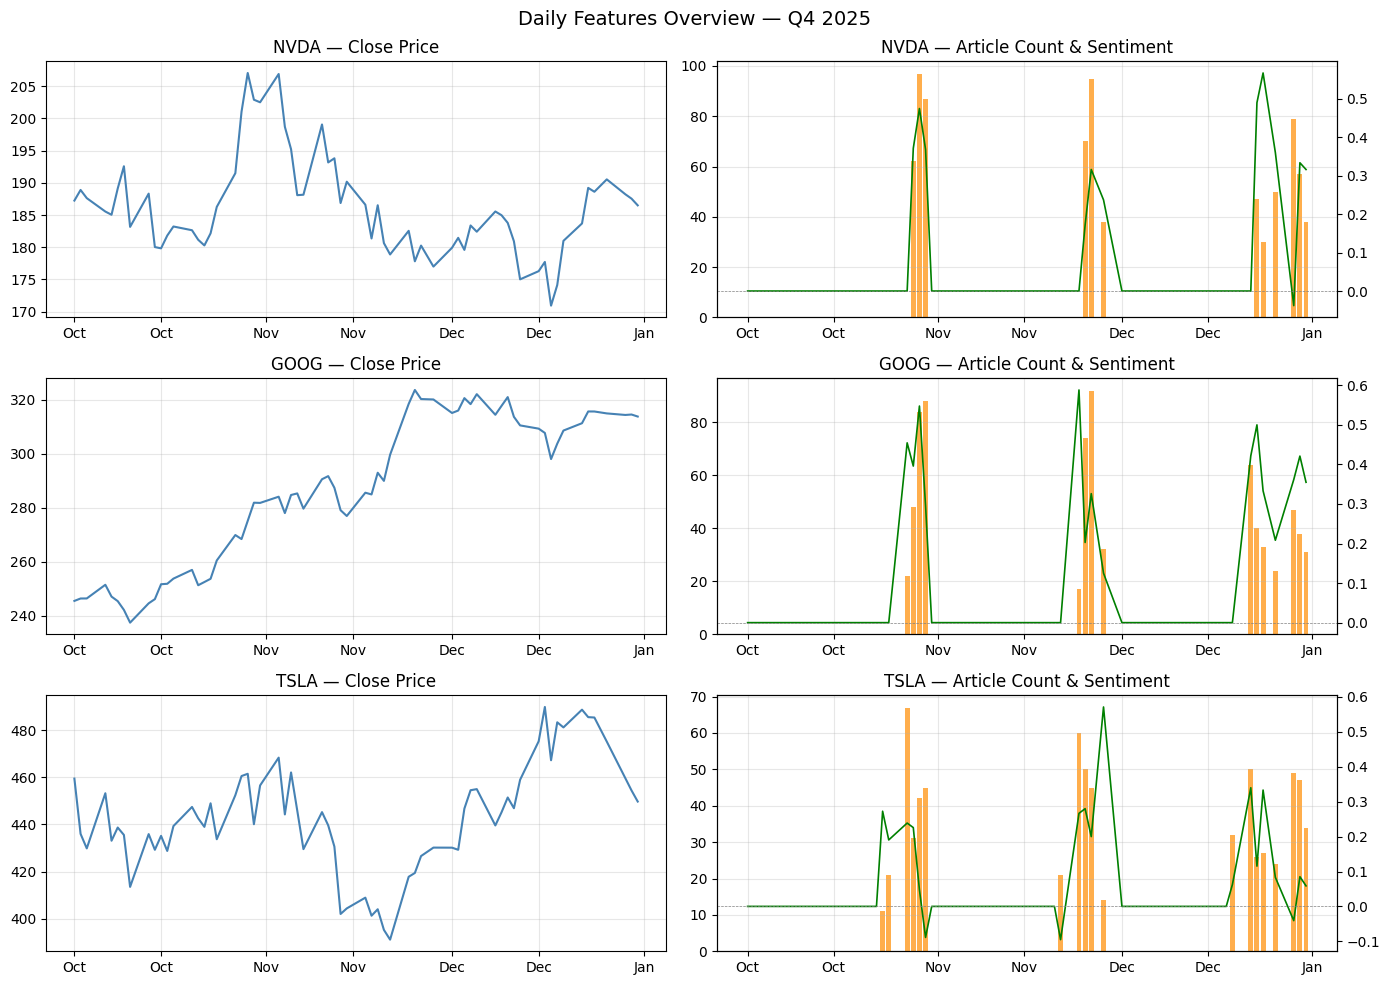

Saved plot to data/dataset_overview.png


In [15]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Daily Features Overview — Q4 2025', fontsize=14)

for i, ticker in enumerate(TICKERS):
    t = daily[daily['ticker'] == ticker]
    
    ax1 = axes[i, 0]
    ax1.plot(t['date'], t['close'], label='close', color='steelblue')
    ax1.set_title(f'{ticker} — Close Price')
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax1.grid(alpha=0.3)
    
    ax2 = axes[i, 1]
    ax2.bar(t['date'], t['article_count'], color='darkorange', alpha=0.7, label='articles')
    ax2_twin = ax2.twinx()
    ax2_twin.plot(t['date'], t['sentiment_mean'], color='green', linewidth=1.2, label='sentiment mean')
    ax2_twin.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax2.set_title(f'{ticker} — Article Count & Sentiment')
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / 'dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved plot to data/dataset_overview.png')

In [16]:
# Check for missing values
print('Missing values:')
print(daily.isnull().sum())
print()
print('Rows per ticker:')
print(daily['ticker'].value_counts().sort_index())
print()
print('Days with 0 articles per ticker:')
print(daily.groupby('ticker')['article_count'].apply(lambda x: (x == 0).sum()))

Missing values:
date                       0
ticker                     0
open                       0
high                       0
low                        0
close                      0
volume                     0
return_1d                  3
return_3d                  9
rolling_volatility_5d     15
article_count              0
sentiment_mean             0
sentiment_max              0
sentiment_min              0
sentiment_std              0
positive_count             0
negative_count             0
net_sentiment_score      146
dtype: int64

Rows per ticker:
ticker
GOOG    64
NVDA    64
TSLA    64
Name: count, dtype: int64

Days with 0 articles per ticker:
ticker
GOOG    49
NVDA    52
TSLA    45
Name: article_count, dtype: int64


## 7. Save Dataset

In [28]:
# Rebuild the final dataset using the reusable session-aware pipeline
ticker_file_map = {
    'NVDA': LLM_FILE_DIR / 'NVDA_q4_2025.csv',
    'GOOG': LLM_FILE_DIR / 'GOOG_q4_2025.csv',
    'TSLA': LLM_FILE_DIR / 'TSLA_q4_2025.csv',
}
paths = DatasetPaths(
    market_dir=LLM_FILE_DIR,
    articles_csv=LLM_FILE_DIR / 'q4_articles' / 'raw_articles_q4_2025.csv',
    output_daily=LLM_DATA_DIR / 'daily_features.csv',
    output_article_sentiments=LLM_DATA_DIR / 'article_sentiments.csv',
)

daily, article_sentiments = build_dataset(paths, ticker_file_map)
daily.to_csv(paths.output_daily, index=False)
print(f'Saved {len(daily)} rows to {paths.output_daily}')
print()
print('Column descriptions:')
col_descriptions = {
    'date': 'Trading date',
    'ticker': 'Stock ticker (NVDA, GOOG, TSLA)',
    'return_1d': '1-day close-to-close return',
    'return_3d': '3-day close-to-close return',
    'rolling_volatility_5d': '5-day rolling std of daily returns',
    'article_count': 'Articles aligned to the trading session',
    'sentiment_mean': 'Mean VADER compound score across aligned articles',
    'sentiment_abs_mean': 'Average absolute sentiment magnitude',
    'sentiment_range': 'Daily max minus min sentiment',
    'sentiment_balance': 'Net positive-vs-negative article balance',
    'sentiment_mean_lag_1d': 'Prior-session mean sentiment',
    'sentiment_mean_lag_3d': '3-session lagged mean sentiment',
    'premarket_article_count': 'Articles published before 9:30 ET',
    'intraday_article_count': 'Articles published between 9:30 and 16:00 ET',
    'after_hours_article_count': 'Articles published after 16:00 ET and shifted forward',
}
for col, desc in col_descriptions.items():
    print(f'  {col:<28} {desc}')


Saved 192 rows to /Users/jasminevu/Documents/Fourth_Year/CS4453/Final Group Project/RL-Project/llm/data/daily_features.csv

Column descriptions:
  date                         Trading date
  ticker                       Stock ticker (NVDA, GOOG, TSLA)
  return_1d                    1-day close-to-close return
  return_3d                    3-day close-to-close return
  rolling_volatility_5d        5-day rolling std of daily returns
  article_count                Articles aligned to the trading session
  sentiment_mean               Mean VADER compound score across aligned articles
  sentiment_abs_mean           Average absolute sentiment magnitude
  sentiment_range              Daily max minus min sentiment
  sentiment_balance            Net positive-vs-negative article balance
  sentiment_mean_lag_1d        Prior-session mean sentiment
  sentiment_mean_lag_3d        3-session lagged mean sentiment
  premarket_article_count      Articles published before 9:30 ET
  intraday_article_coun

In [29]:
article_sentiments.to_csv(paths.output_article_sentiments, index=False)
print('Saved article-level sentiments to data/article_sentiments.csv')
article_sentiments.head()


Saved article-level sentiments to data/article_sentiments.csv


,article_id,ticker,headline,source_tier,quality_score,published_at_utc,published_at_et,news_session,aligned_trading_date,sentiment_vader
0,0cb7e60f113fe7702090436b,GOOG,Google wraps up best year on Wall Street since...,high,10,2025-12-31 16:06:31+00:00,2025-12-31 11:06:31-05:00,intraday,2025-12-31,0.8720
1,5c72dfab506d75bab9e867ab,GOOG,Space and defense boom lifted these satellite ...,high,10,2025-12-31 07:00:01+00:00,2025-12-31 02:00:01-05:00,premarket,2025-12-31,0.7964
2,b94b504dd31800ac901f6c73,GOOG,"Meta acquires intelligent agent firm Manus, ca...",high,10,2025-12-29 22:18:51+00:00,2025-12-29 17:18:51-05:00,after_hours,2025-12-30,0.6705
3,88c4f8f1663b07aa9fe78742,GOOG,Jim Cramer’s guide to investing: Pick out the ...,high,10,2025-12-29 18:31:22+00:00,2025-12-29 13:31:22-05:00,intraday,2025-12-29,0.6908
4,6d56ce647ca57d55d821d415,GOOG,Talk of the Tape: Next phase of the AI trade,high,10,2025-12-29 15:31:01+00:00,2025-12-29 10:31:01-05:00,intraday,2025-12-29,0.4939
